# How This Blog Is Built — figures

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josephrich98/joseph_rich_blog/blob/main/posts/how-this-blog-is-built/notebook.ipynb)

This post is an explainer about the blog's own toolchain, so it ships **no data**. The single figure is a schematic of the commit-to-deploy pipeline, drawn entirely from box/arrow geometry so it is fully reproducible. Running this notebook top-to-bottom regenerates `figures/pipeline.png`, which `main.md` embeds. The same code lives standalone in [`scripts/make_figures.py`](scripts/make_figures.py).

In [1]:
# NBVAL_IGNORE_OUTPUT
import os

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

FIG = "figures"
os.makedirs(FIG, exist_ok=True)

# Local steps are one hue, automation another, so the reader can see at a glance
# how little of the pipeline is manual.
LOCAL = "#1f4e79"   # things I do by hand
AUTO = "#2e7d32"    # things that happen automatically
GATE = "#9a6700"    # the branch / merge gate
INK = "#1b1b1b"

In [2]:
def box(ax, xy, w, h, text, face, *, fontsize=10.5, text_color="white"):
    """Draw a rounded box centered at xy with text."""
    x, y = xy
    ax.add_patch(FancyBboxPatch(
        (x - w / 2, y - h / 2), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=0, facecolor=face, zorder=2,
    ))
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize,
            color=text_color, zorder=3, linespacing=1.25)


def arrow(ax, p0, p1, color=INK, style="-|>", lw=1.8, ls="-"):
    ax.add_patch(FancyArrowPatch(
        p0, p1, arrowstyle=style, mutation_scale=14, linewidth=lw,
        linestyle=ls, color=color, shrinkA=2, shrinkB=2, zorder=1,
    ))

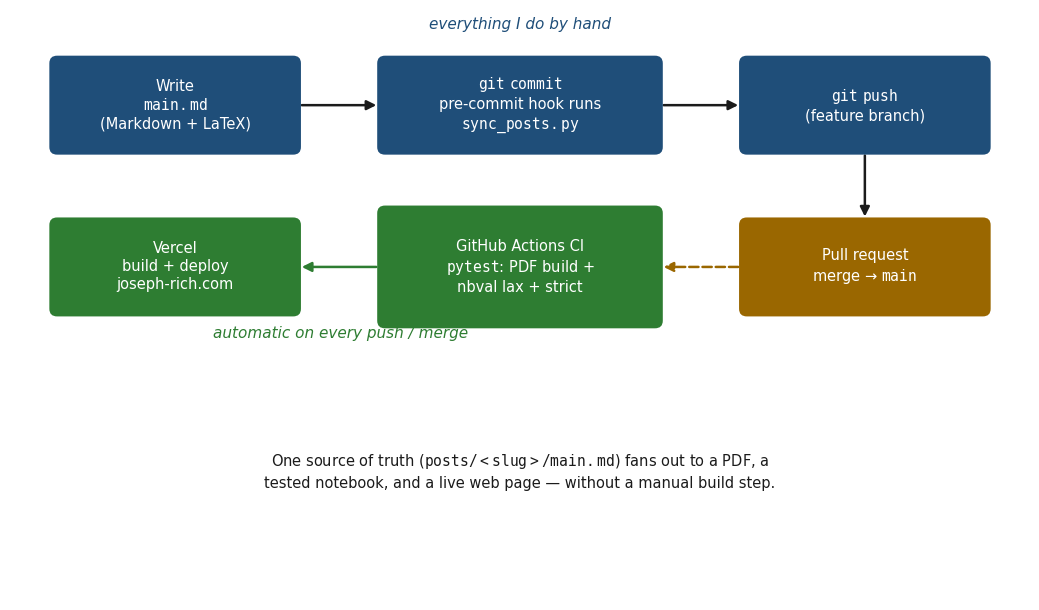

In [3]:
# NBVAL_IGNORE_OUTPUT
fig, ax = plt.subplots(figsize=(10.5, 6.2))
ax.set_xlim(0, 10.5)
ax.set_ylim(0, 6.2)
ax.axis("off")

w, h = 2.55, 1.0

# Top lane: the manual part (write -> commit -> push).
box(ax, (1.7, 5.2), w, h, "Write\n$\\tt main.md$\n(Markdown + LaTeX)", LOCAL)
box(ax, (5.25, 5.2), w + 0.35, h,
    "$\\tt git\\ commit$\npre-commit hook runs\n$\\tt sync\\_posts.py$", LOCAL)
box(ax, (8.8, 5.2), w, h, "$\\tt git\\ push$\n(feature branch)", LOCAL)
arrow(ax, (1.7 + w / 2, 5.2), (5.25 - (w + 0.35) / 2, 5.2))
arrow(ax, (5.25 + (w + 0.35) / 2, 5.2), (8.8 - w / 2, 5.2))
ax.text(5.25, 6.0, "everything I do by hand", ha="center", fontsize=11,
        style="italic", color=LOCAL)

# Gate: pull request / merge to main.
box(ax, (8.8, 3.5), w, h, "Pull request\nmerge \u2192 $\\tt main$", GATE)
arrow(ax, (8.8, 5.2 - h / 2), (8.8, 3.5 + h / 2))

# Bottom lane: automation (CI gates the merge; deploy follows).
box(ax, (5.25, 3.5), w + 0.35, h + 0.25,
    "GitHub Actions CI\n$\\tt pytest$: PDF build +\nnbval lax + strict", AUTO)
box(ax, (1.7, 3.5), w, h, "Vercel\nbuild + deploy\njoseph-rich.com", AUTO)
# CI runs on the pushed branch and blocks the merge (dashed = "must pass").
arrow(ax, (8.8 - w / 2, 3.5), (5.25 + (w + 0.35) / 2, 3.5), color=GATE, ls="--")
# Merge to main triggers the deploy.
arrow(ax, (5.25 - (w + 0.35) / 2, 3.5), (1.7 + w / 2, 3.5), color=AUTO)
ax.text(3.4, 2.75, "automatic on every push / merge", ha="center", fontsize=11,
        style="italic", color=AUTO)

ax.text(5.25, 1.35,
        "One source of truth ($\\tt posts/<slug>/main.md$) fans out to a PDF, a\n"
        "tested notebook, and a live web page \u2014 without a manual build step.",
        ha="center", va="center", fontsize=10.5, color=INK, linespacing=1.4)

fig.tight_layout()
fig.savefig(os.path.join(FIG, "pipeline.png"), dpi=200, bbox_inches="tight")
plt.show()